In [1]:
#Core Business Problem
#Context: Heart disease is a leading cause of death globally.

#Goal: Develop a predictive model to determine if a patient has heart disease based on their medical data.

#Business Value & Impact
#Early Intervention: Enables doctors to identify at-risk patients sooner.

#Proactive Care: Facilitates the start of early treatment plans.

#Risk Reduction: Helps mitigate severe complications by managing the disease proactively.

#Life Preservation: Directly contributes to saving lives through timely medical attention.

In [2]:
'''Column	Meaning
age	        age of patient
sex	        0 female, 1 male
cp	        chest pain type
trestbps	resting blood pressure
chol	    cholesterol
fbs	        fasting blood sugar
restecg  	ECG result
thalach	    max heart rate
exang	    exercise induced angina
oldpeak	    ST depression
slope	    slope
ca	        major vessels
thal	    thalassemia
target	    heart disease (0/1)'''

'Column\tMeaning\nage\t        age of patient\nsex\t        0 female, 1 male\ncp\t        chest pain type\ntrestbps\tresting blood pressure\nchol\t    cholesterol\nfbs\t        fasting blood sugar\nrestecg  \tECG result\nthalach\t    max heart rate\nexang\t    exercise induced angina\noldpeak\t    ST depression\nslope\t    slope\nca\t        major vessels\nthal\t    thalassemia\ntarget\t    heart disease (0/1)'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('heart.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.shape

(1025, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [9]:
df.isnull().sum().sum()

0

In [10]:
df['target'].value_counts()

1    526
0    499
Name: target, dtype: int64

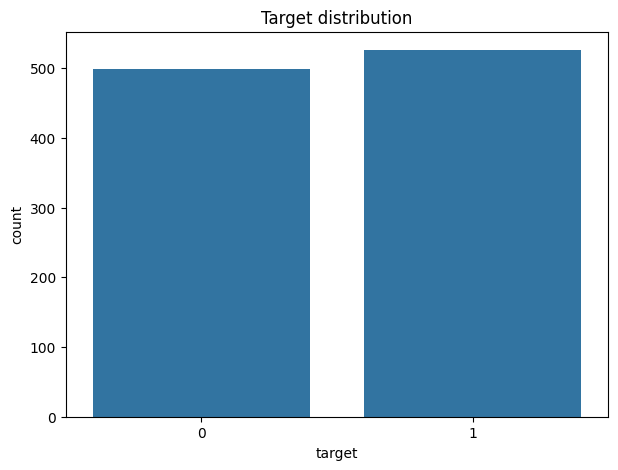

In [11]:
plt.figure(figsize = (7,5))
sns.countplot(x = 'target',data = df)
plt.title('Target distribution')
plt.show()

In [12]:
# target is not biased it is approximately equal

In [13]:
df.duplicated().sum()

723

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

0

In [16]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [17]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [18]:
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']
num_cols = ['age','trestbps','chol','thalach','oldpeak']

In [19]:
# Univariate Analysis

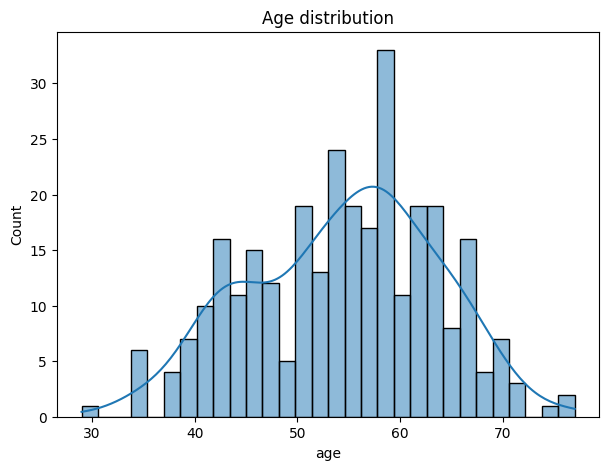

In [20]:
plt.figure(figsize = (7,5))
sns.histplot(x = 'age',data = df, bins = 30,kde = True)
plt.title('Age distribution')
plt.show()

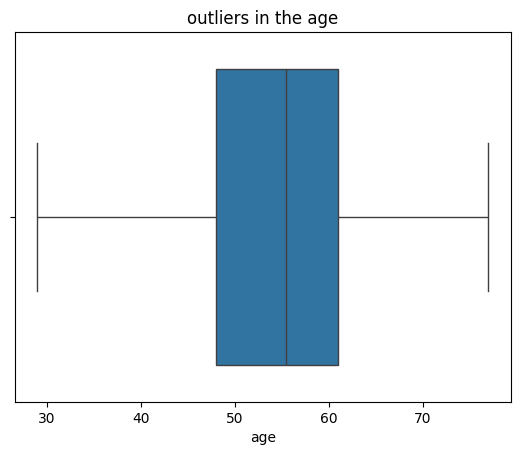

In [21]:
sns.boxplot(x = df['age'])
plt.title('outliers in the age')
plt.show()

In [22]:
# more patient are between 40 and 65 and no outliers are there

Text(0.5, 1.0, 'chol Distribution')

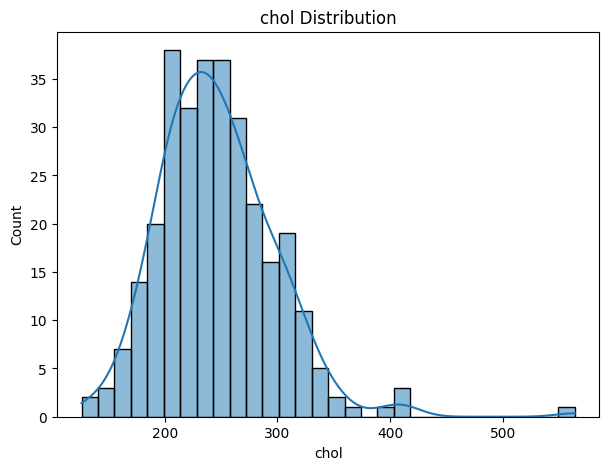

In [23]:
plt.figure(figsize = (7,5))
sns.histplot(df['chol'],bins = 30,kde = True)
plt.title('chol Distribution')

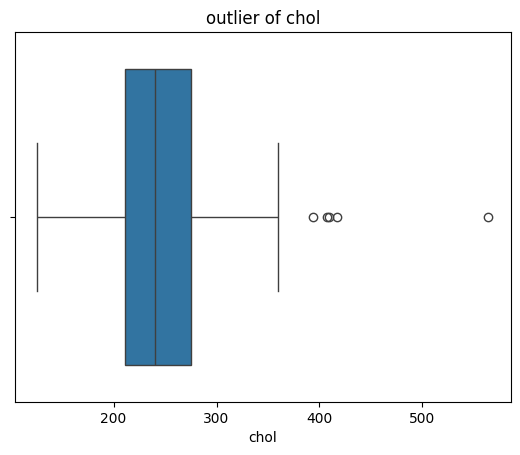

In [24]:
sns.boxplot(x = df['chol'])
plt.title('outlier of chol')
plt.show()

In [25]:
# more patients suffuring from cholestrol between 200 and 300 and some extreme cholestrol patient are there that have above 400 chol
# and chol is right skewed

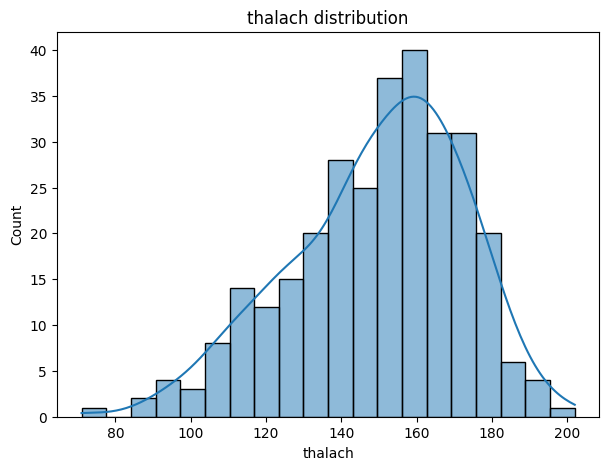

In [26]:
plt.figure(figsize = (7,5))
sns.histplot(df['thalach'],bins = 20,kde = True)
plt.title('thalach distribution')
plt.show()

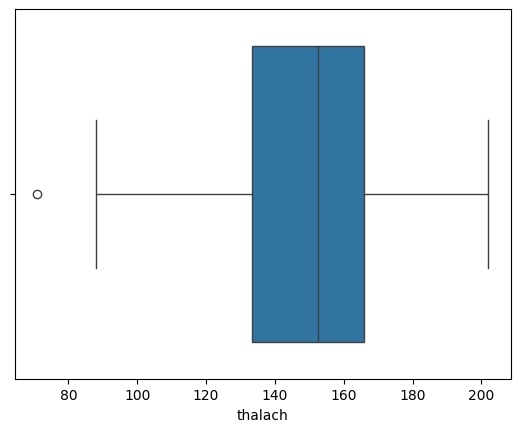

In [27]:
sns.boxplot(x = df['thalach'])
plt.show()

In [28]:
#Most values between 120–170.
#Normal distribution pattern.

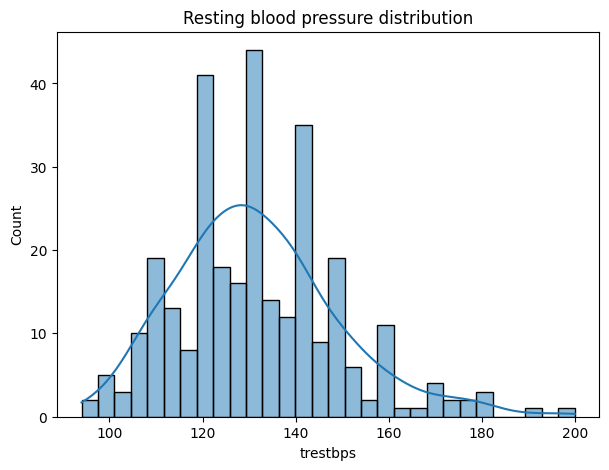

<Axes: xlabel='trestbps'>

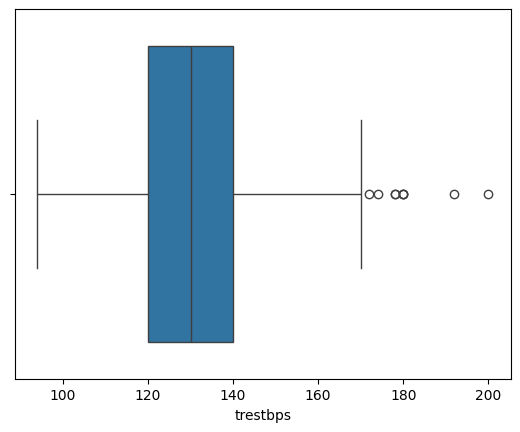

In [29]:
plt.figure(figsize = (7,5))
sns.histplot(df['trestbps'],bins = 30,kde = True)
plt.title('Resting blood pressure distribution')
plt.show()
sns.boxplot(x = df['trestbps'])


In [30]:
# most patient has resting blood pressure between 120 and 140 and some outlier are there  curve is right skewed

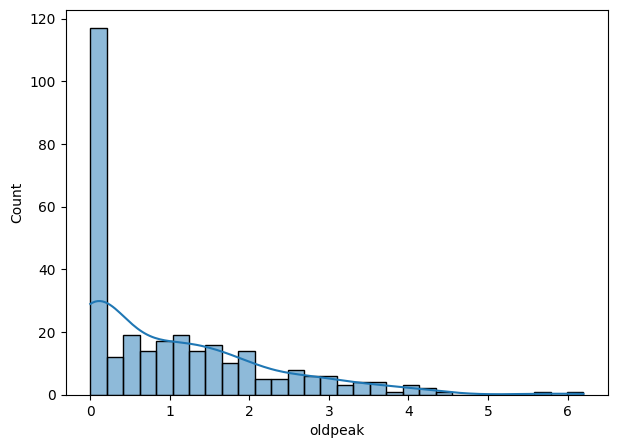

<Axes: xlabel='oldpeak'>

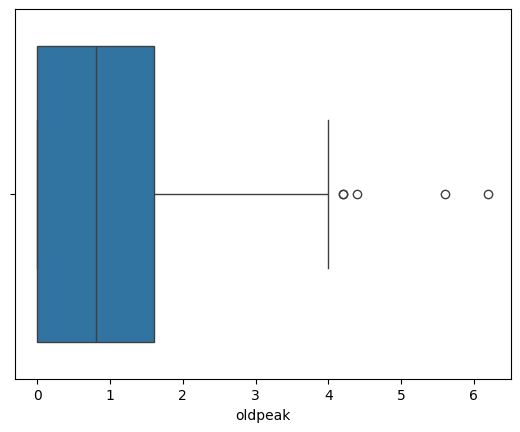

In [31]:
plt.figure(figsize = (7,5))
sns.histplot(x = 'oldpeak',kde = True,bins = 30,data = df)
plt.show()
sns.boxplot(x = df['oldpeak'])

In [32]:
# Categorical analysis

In [33]:
#categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']

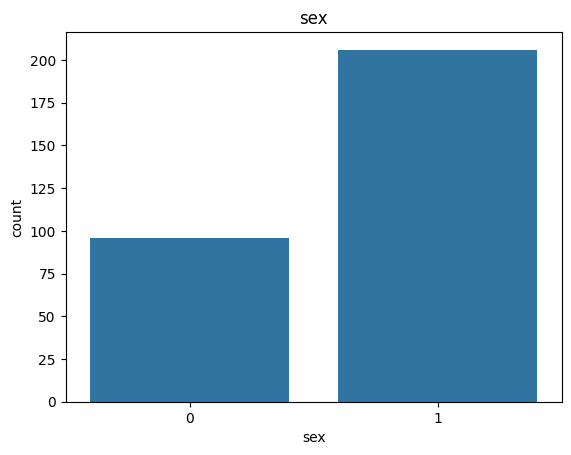

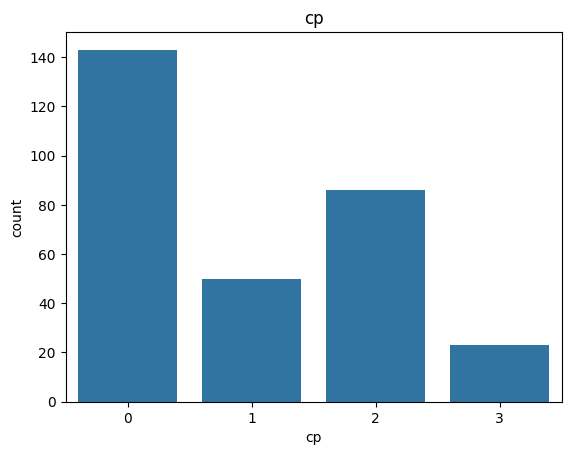

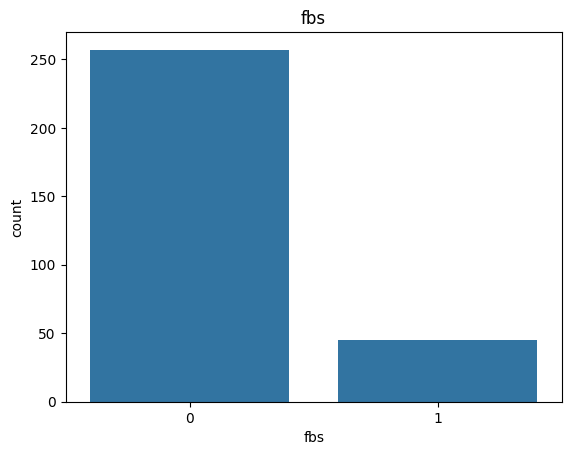

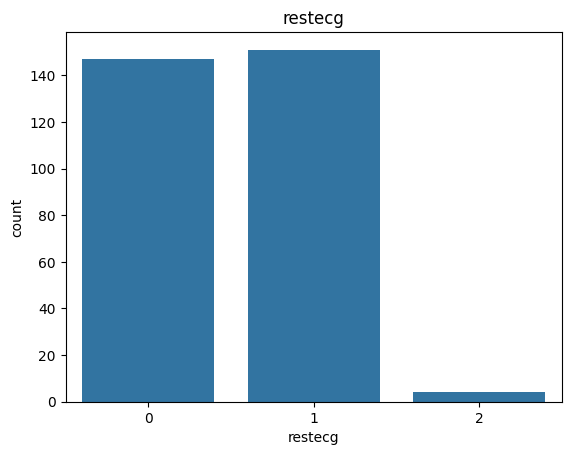

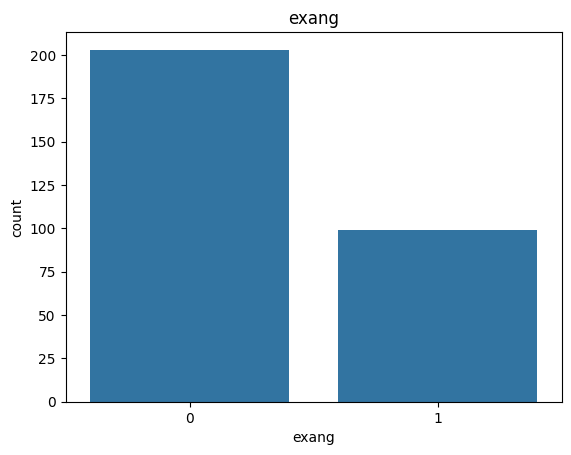

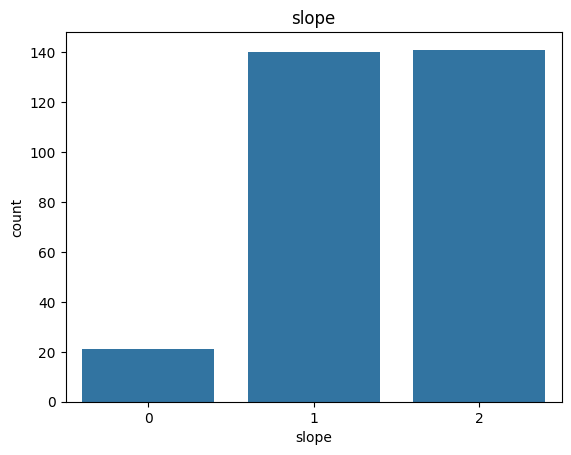

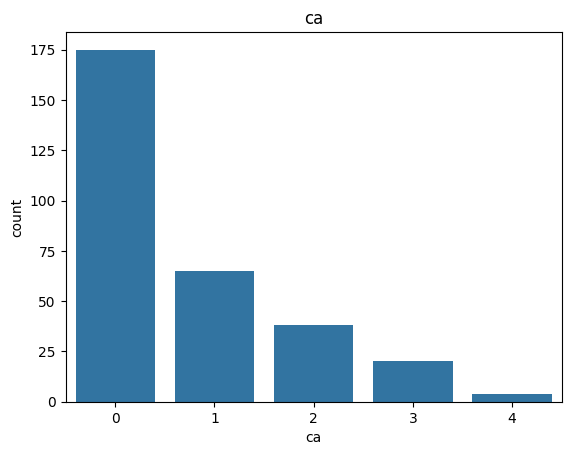

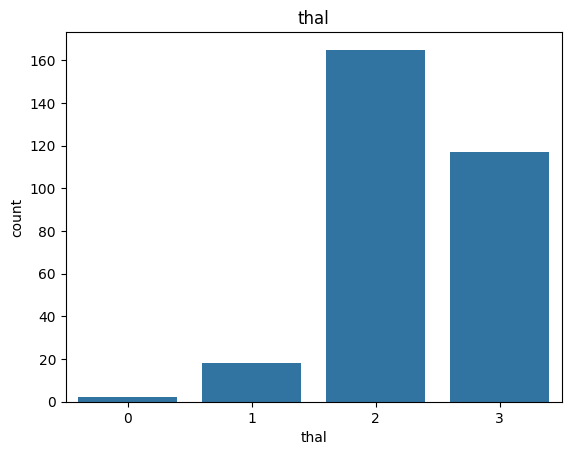

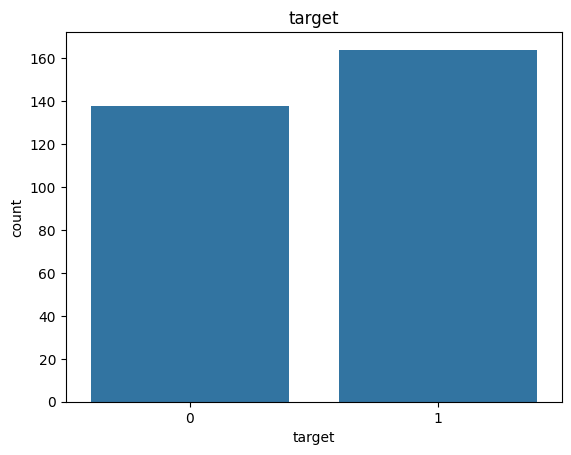

In [34]:
for col in categorical_cols:
    sns.countplot(x = col,data = df)
    plt.title(col)
    plt.show()
    

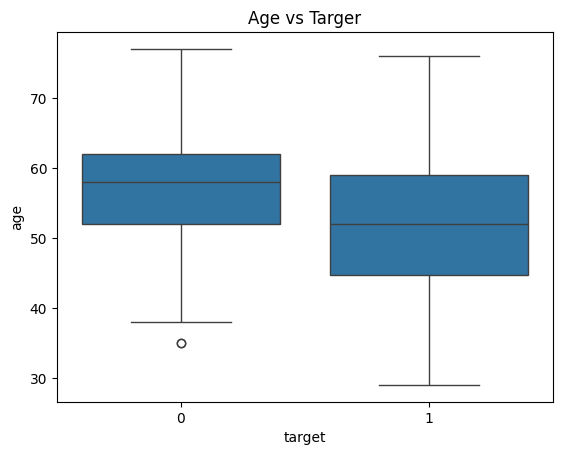

In [35]:
# Age Vs Targer
sns.boxplot(x = 'target',y = 'age',data = df)
plt.title('Age vs Targer')
plt.show()

In [36]:
# most patient between 45 and 55

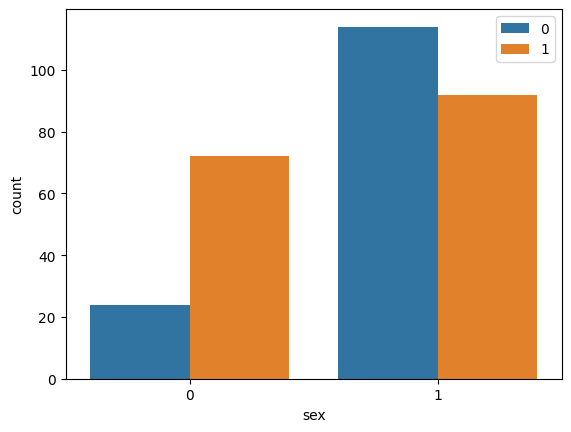

In [37]:
 sns.countplot(x = 'sex',hue = 'target',data = df)
plt.legend()
plt.show()

In [38]:
df.groupby('sex')['target'].value_counts()

sex  target
0    1          72
     0          24
1    0         114
     1          92
Name: target, dtype: int64

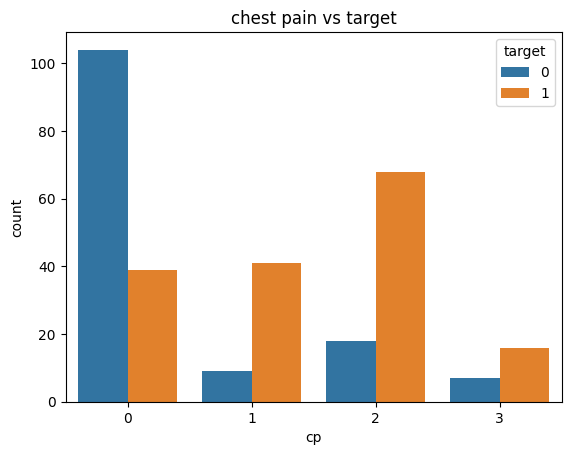

In [39]:
sns.countplot(x = 'cp',hue = 'target',data = df)
plt.title('chest pain vs target')
plt.show()

In [40]:
df.groupby('cp')['target'].value_counts()

cp  target
0   0         104
    1          39
1   1          41
    0           9
2   1          68
    0          18
3   1          16
    0           7
Name: target, dtype: int64

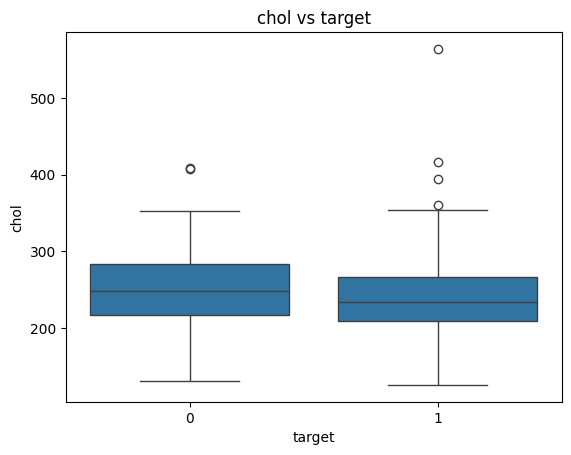

In [41]:
sns.boxplot(x = 'target',y = 'chol',data = df)
plt.title('chol vs target')
plt.show()

In [42]:
# heart diseases patient often has higher cholestrol

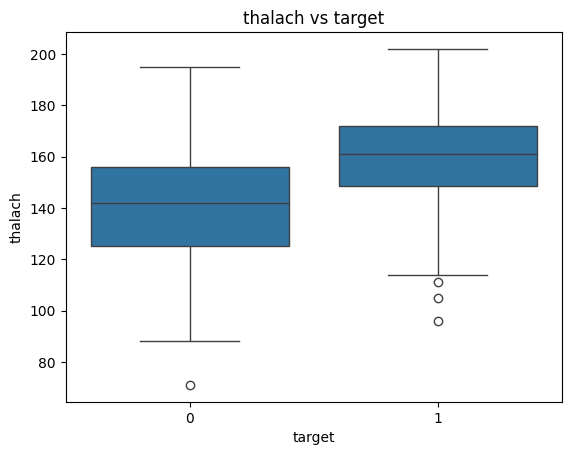

In [43]:
sns.boxplot(x = 'target',y = 'thalach',data = df)
plt.title('thalach vs target')
plt.show()

In [44]:
# patient that has heart disease has tendency to lower heart rate

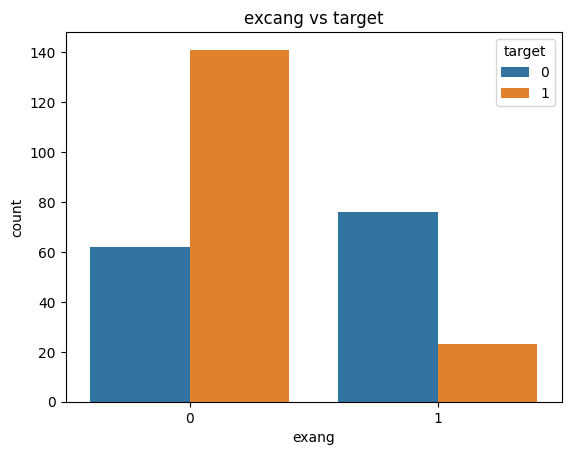

In [45]:
sns.countplot(x = 'exang',hue = 'target',data = df)
plt.title('excang vs target')
plt.show()

In [46]:
#Exercise induced angina is strongly associated with heart disease.Important feature.

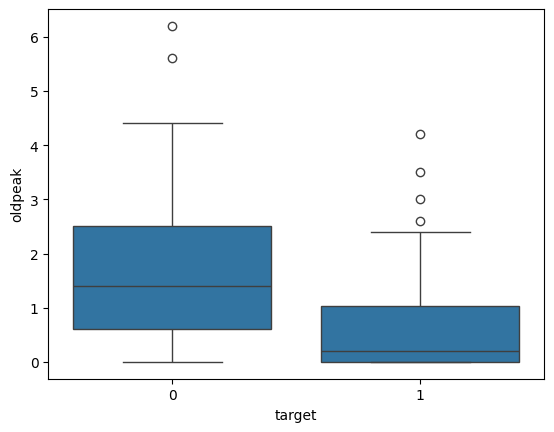

In [47]:
sns.boxplot(x = 'target',y = 'oldpeak',data = df)
plt.show()

In [48]:
# Lower oldpeak values are more common in heart disease patients.

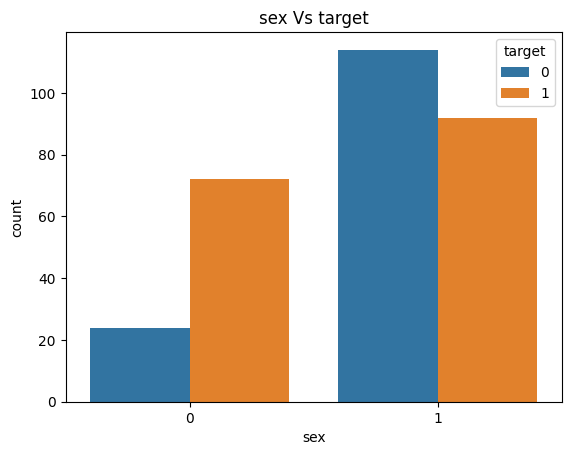

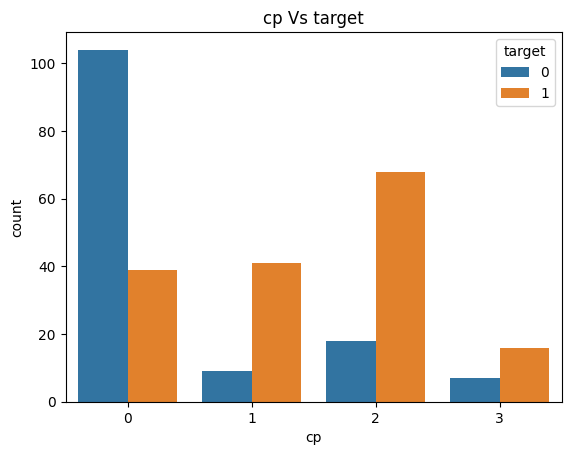

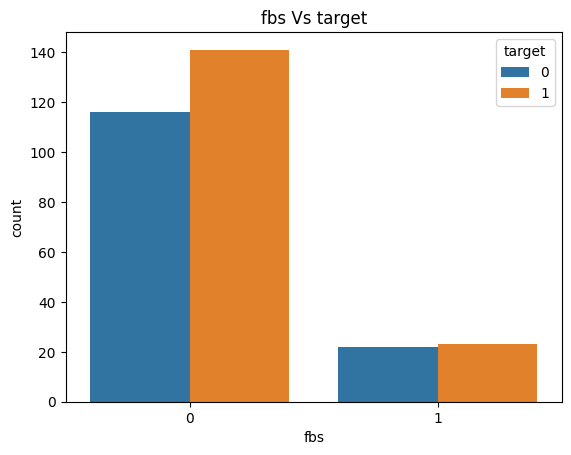

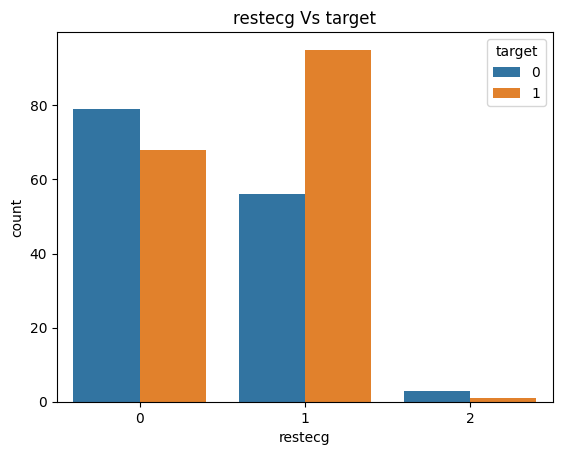

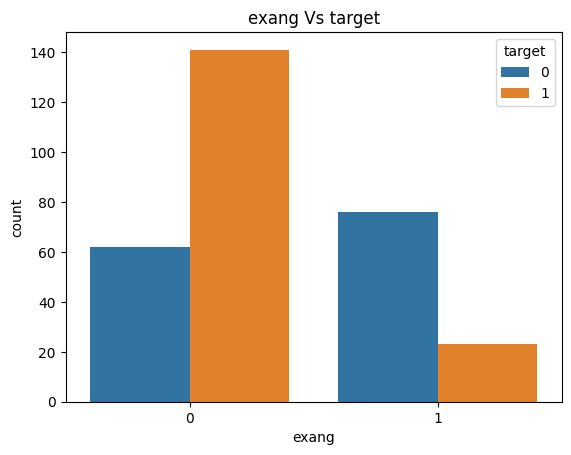

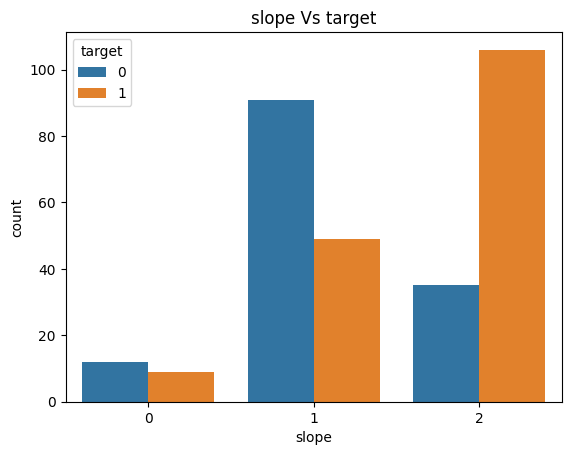

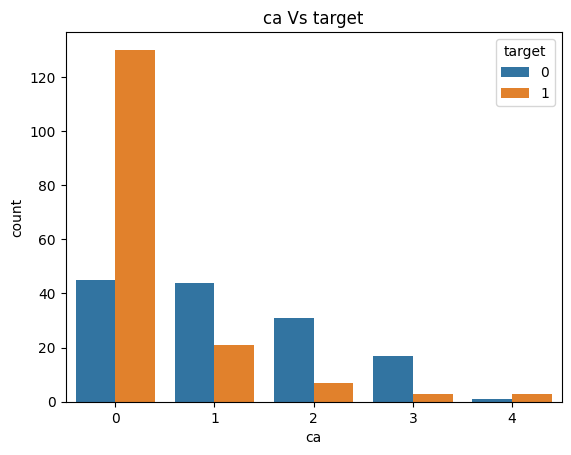

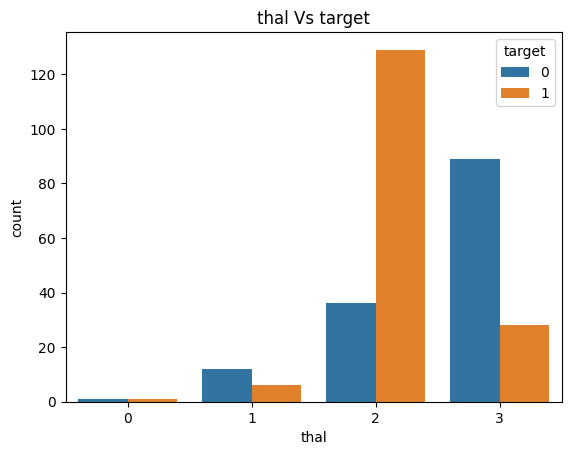

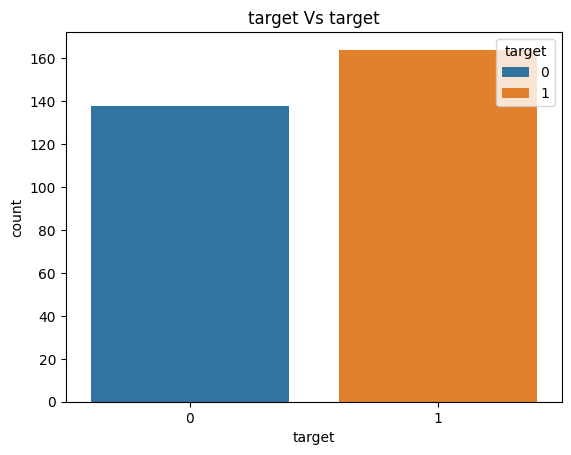

In [49]:
for col in categorical_cols:
    sns.countplot(x = col,hue = 'target',data = df)
    plt.title(col + ' Vs target')
    plt.show()

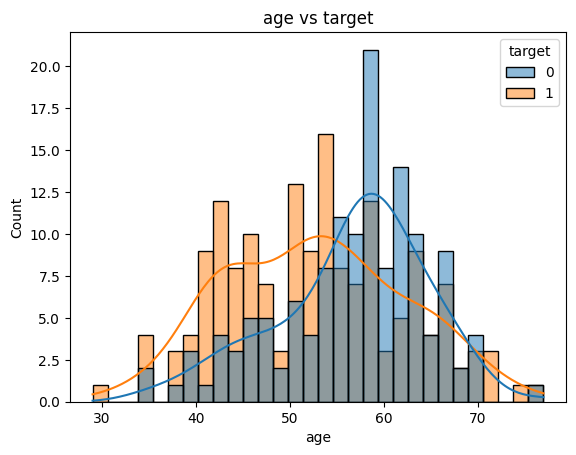

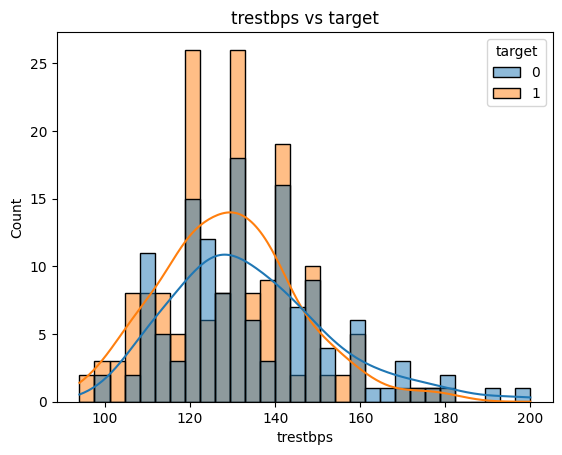

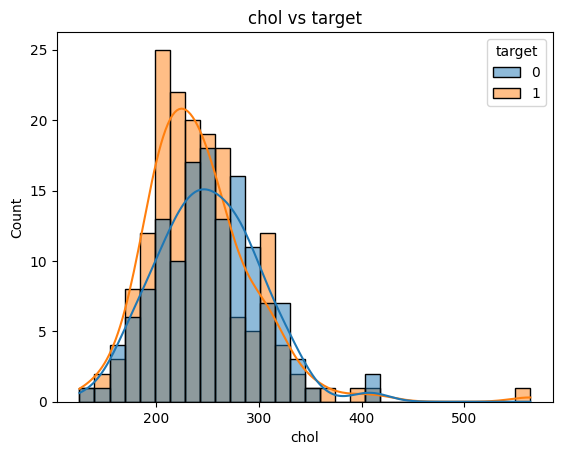

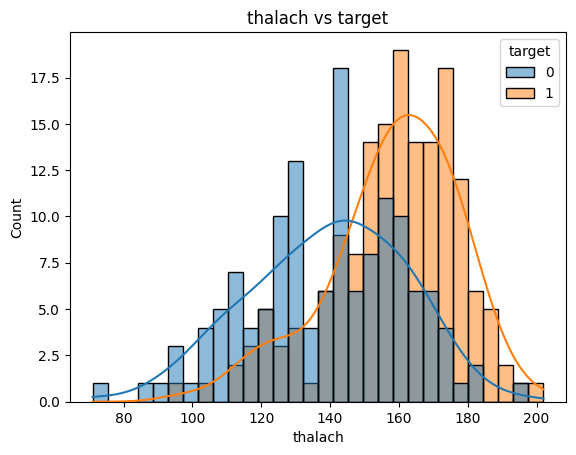

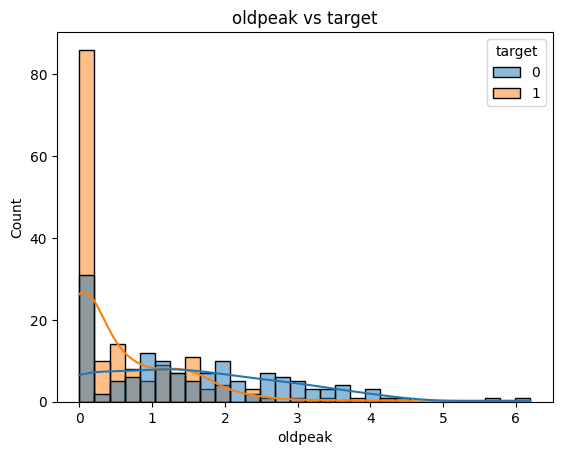

In [50]:
for col in num_cols:
    sns.histplot(x = col,hue = 'target',data = df,kde = True,bins = 30)
    plt.title(col + ' vs target')
    plt.show()
    

In [51]:
df.groupby('target').mean().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.60,0.83,0.48,134.40,251.09,0.16,0.45,139.10,0.55,1.59,1.17,1.17,2.54
1,52.59,0.56,1.37,129.25,242.64,0.14,0.59,158.38,0.14,0.59,1.59,0.34,2.12


In [52]:
# multivariate analysis

In [53]:
df.corr()['target'].sort_values(ascending = False).round(2)

target      1.00
cp          0.43
thalach     0.42
slope       0.34
restecg     0.13
fbs        -0.03
chol       -0.08
trestbps   -0.15
age        -0.22
sex        -0.28
thal       -0.34
ca         -0.41
oldpeak    -0.43
exang      -0.44
Name: target, dtype: float64

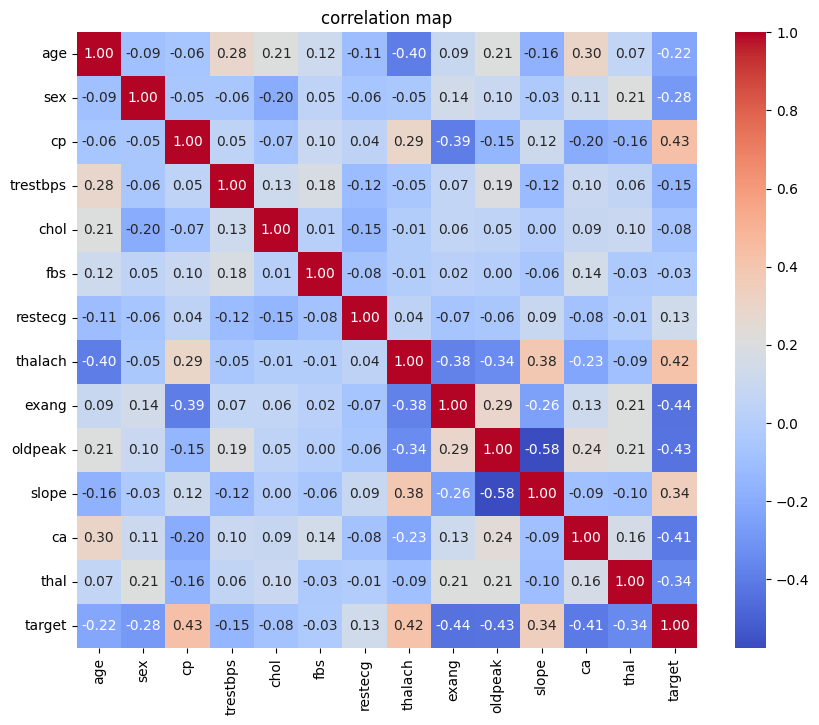

In [54]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(),annot = True,cmap = 'coolwarm',fmt = '.2f')
plt.title('correlation map')
plt.show()

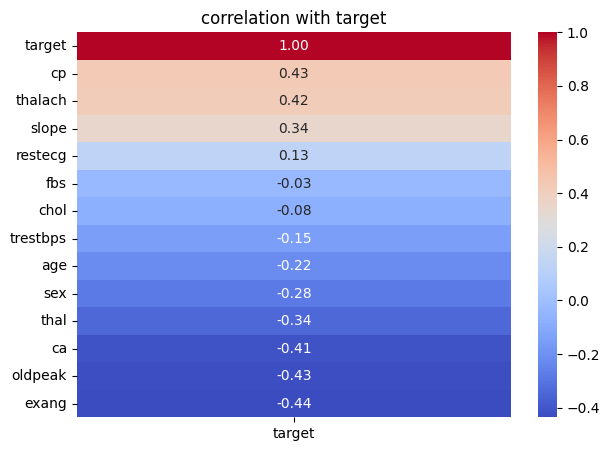

In [55]:
plt.figure(figsize = (7,5))
sns.heatmap(df.corr()[['target']].sort_values(by = 'target',ascending = False),annot = True,cmap = 'coolwarm',
            fmt = '.2f')
plt.title('correlation with target')
plt.show()

In [56]:
#cp and thalach has strong positive correlation and oldpeak and exang has negative collrelation

In [57]:
# Hypothesis Testing

In [58]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [59]:
num_col = ['age','trestbps','chol','thalach','oldpeak']
cat_col = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
           

In [60]:
from scipy import stats

In [61]:
for col in num_col:
    group1 = df[df['target'] == 1][col]
    group0 = df[df['target'] == 0][col]
    stat,p_value = stats.ttest_ind(group1,group0)
    print(col,'p_value:',p_value.round(2))
    

age p_value: 0.0
trestbps p_value: 0.01
chol p_value: 0.16
thalach p_value: 0.0
oldpeak p_value: 0.0


In [62]:
# age,trestbps,thalach and oldpeak have significant relationship with target but chol doesn't have significant relationship with target


In [63]:
for col in cat_col:
    cont_table = pd.crosstab(df['target'],df[col])
    stat,p_value,dof,expected_table = stats.chi2_contingency(cont_table)
    print(col,'p_value:',p_value.round(2))

sex p_value: 0.0
cp p_value: 0.0
fbs p_value: 0.76
restecg p_value: 0.01
exang p_value: 0.0
slope p_value: 0.0
ca p_value: 0.0
thal p_value: 0.0


In [64]:
# sex,cp,restecg,exang,slope,ca and thal have significant relationship but fbs doesn't have significant relationship

In [65]:
#Why perform hypothesis testing if we already saw correlation?

#Answer:
#Correlation shows relationship strength, but hypothesis testing
#statistically confirms whether that relationship is significant or occurred by chance.

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X = df.drop(['target'],axis = 1)
y = df['target']

In [68]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [69]:
# Feature Scaling

In [70]:
from sklearn.preprocessing import StandardScaler

In [71]:
scaler = StandardScaler()

In [72]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [73]:
from sklearn.linear_model import LogisticRegression


In [74]:
lr = LogisticRegression()

In [75]:
lr.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [76]:
lr_pred = lr.predict(x_test_scaled)

In [77]:
from sklearn.tree import DecisionTreeClassifier

In [78]:
dt = DecisionTreeClassifier()

In [79]:
dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [80]:
dt_pred = dt.predict(x_test)

In [81]:
from sklearn.ensemble import RandomForestClassifier

In [82]:
rf = RandomForestClassifier()

In [83]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [84]:
rf_pred = rf.predict(x_test)

In [85]:
from sklearn.neighbors import KNeighborsClassifier

In [87]:
knn = KNeighborsClassifier()

In [88]:
knn.fit(x_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [89]:
knn_pred = knn.predict(x_test_scaled)

In [90]:
from sklearn.svm import SVC

In [93]:
svm = SVC(probability = True)

In [94]:
svm.fit(x_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [95]:
svm_pred = svm.predict(x_test_scaled)

In [97]:
from sklearn.metrics import accuracy_score

In [100]:
print('LogisticRegression:',accuracy_score(y_test,lr_pred))
print('DecisionTree:',accuracy_score(y_test,dt_pred))
print('RandomForest:',accuracy_score(y_test,rf_pred))
print('KNN:',accuracy_score(y_test,knn_pred))
print('SVM:',accuracy_score(y_test,svm_pred))

LogisticRegression: 0.7704918032786885
DecisionTree: 0.7377049180327869
RandomForest: 0.8524590163934426
KNN: 0.7377049180327869
SVM: 0.7868852459016393


In [101]:
from sklearn.metrics import classification_report,confusion_matrix

In [102]:
rf_cm = confusion_matrix(y_test,rf_pred)
rf_cf = classification_report(y_test,rf_pred)
print(rf_cm,   rf_cf)

[[26  6]
 [ 3 26]]               precision    recall  f1-score   support

           0       0.90      0.81      0.85        32
           1       0.81      0.90      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



In [107]:
 from sklearn.metrics import roc_auc_score

In [108]:
rf_probs = rf.predict_proba(x_test)[:,1]
print('Roc_Auc:', roc_auc_score(y_test,rf_probs))

Roc_Auc: 0.8744612068965517


In [111]:
feature_importance = pd.Series(rf.feature_importances_,index = X.columns)
print(feature_importance.sort_values(ascending = False).round(3))

cp          0.158
oldpeak     0.130
thalach     0.115
thal        0.101
ca          0.098
age         0.084
trestbps    0.075
chol        0.073
exang       0.045
slope       0.044
sex         0.036
restecg     0.032
fbs         0.009
dtype: float64


In [112]:
from sklearn.model_selection import cross_val_score

In [114]:
cv_score = cross_val_score(rf,X,y,cv = 5)
print('CV_mean:',cv_score.mean())

CV_mean: 0.8310382513661201


In [115]:
from sklearn.model_selection import GridSearchCV

In [122]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X, y)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
Best Score: 0.9168234928651596


In [123]:
best_rf = RandomForestClassifier(max_depth = 15,min_samples_leaf = 4,min_samples_split = 10,n_estimators = 500)

In [124]:
best_rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [129]:
best_pred = best_rf.predict(x_test)

In [130]:
print('Accuracy_best_rf:',accuracy_score(y_test,rf_pred))
print('Classification_Report_best_rf:',classification_report(y_test,rf_pred))
print('Confusion_Matrix_best_rf:',confusion_matrix(y_test,rf_pred))

Accuracy_best_rf: 0.8360655737704918
Classification_Report_best_rf:               precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

Confusion_Matrix_best_rf: [[25  7]
 [ 3 26]]


In [131]:
best_rf_probs = best_rf.predict_proba(x_test)[:,1]
print('best_rf_roc_auc:',roc_auc_score(y_test,best_rf_probs))

best_rf_roc_auc: 0.8987068965517242


In [132]:
from sklearn.metrics import roc_curve

In [133]:
fpr,tpr,threshold = roc_curve(y_test,best_rf_probs)

In [135]:
roc_score = roc_auc_score(y_test,best_rf_probs)

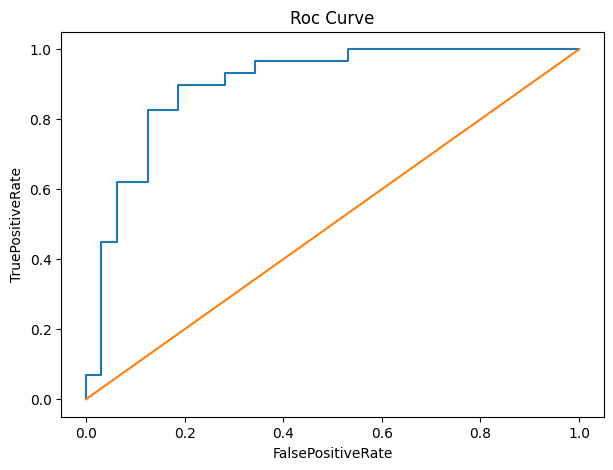

In [137]:
plt.figure(figsize = (7,5))
plt.plot(fpr,tpr,label = f'Random Forest (AUC = {roc_score:.2f})')
plt.plot([0,1],[0,1])
plt.title('Roc Curve')
plt.xlabel('FalsePositiveRate')
plt.ylabel('TruePositiveRate')
plt.show()